<a href="https://colab.research.google.com/github/leonnmarcoo/CCADMACL_EXERCISES_COM232/blob/main/Exercise_3B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3B

In this exercise, you will explore how the DBSCAN clustering algorithm identifies dense groups and outliers in the Pokémon statistics dataset. You will analyze the dataset, scale features, determine DBSCAN parameters, run DBSCAN, and interpret the clustering results.

In [236]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sklearn
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [237]:
# Download latest version
path = kagglehub.dataset_download("abcsds/pokemon")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pokemon' dataset.
Path to dataset files: /kaggle/input/pokemon


In [238]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Load the Dataset (8 pts)

Load the Pokémon dataset into a pandas DataFrame.

Show the first five rows (3 pts)

In [239]:
df.head(5)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False



How many Pokémon are in the dataset? (2 pts)


In [240]:
len(df)

800


List all columns available (3 pts)

In [241]:
df.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

## 2: Select Features & Clean the Data (8 pts)

Select the numeric features needed for clustering (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed).

In [242]:
new_df = df[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']]
new_df

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,45,49,49,65,65,45
1,60,62,63,80,80,60
2,80,82,83,100,100,80
3,80,100,123,122,120,80
4,39,52,43,60,50,65
...,...,...,...,...,...,...
795,50,100,150,100,150,50
796,50,160,110,160,110,110
797,80,110,60,150,130,70
798,80,160,60,170,130,80


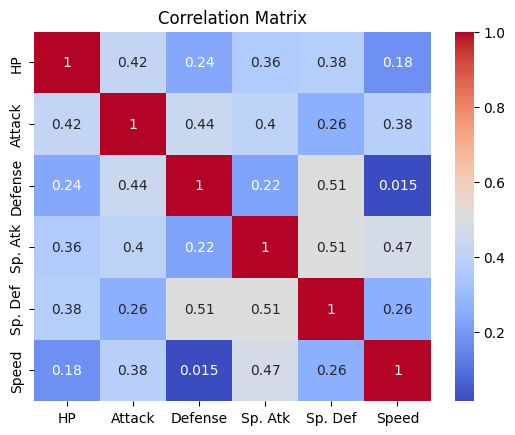

In [243]:
correlation_matrix = new_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [244]:
selected_df = df[['HP', 'Attack', 'Defense']]
selected_df

,HP,Attack,Defense
0,45,49,49
1,60,62,63
2,80,82,83
3,80,100,123
4,39,52,43
...,...,...,...
795,50,100,150
796,50,160,110
797,80,110,60
798,80,160,60


Are there any missing values? (2 pts)

In [245]:
selected_df.isnull().sum()

,0
HP,0
Attack,0
Defense,0


If missing values exist, describe how you handled them (3 pts)

### Data Visualization

In [246]:
fig = px.scatter_3d(selected_df, x='HP', y='Attack', z='Defense')
fig.show()

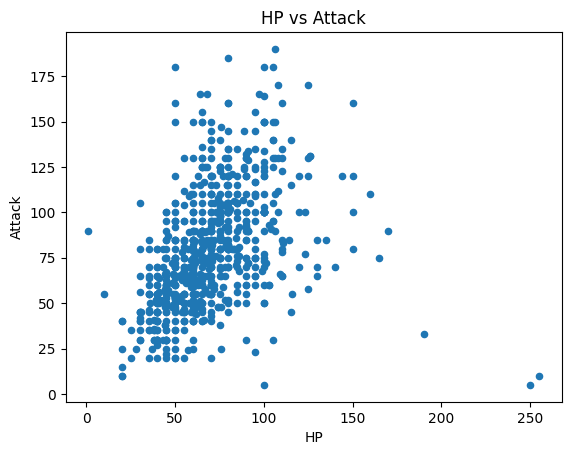

In [247]:
selected_df.plot.scatter(x='HP', y='Attack')
plt.xlabel('HP')
plt.ylabel('Attack')
plt.title('HP vs Attack')
plt.show()

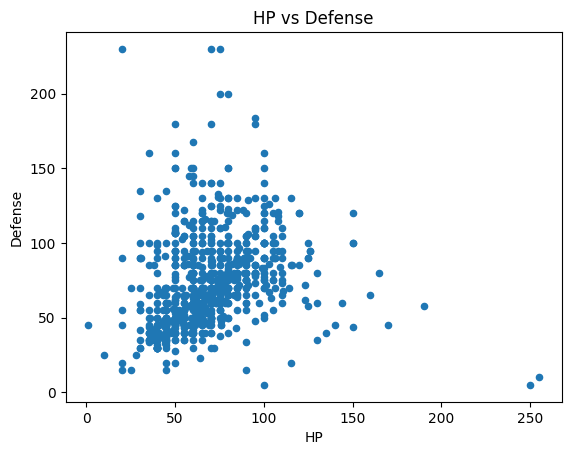

In [248]:
selected_df.plot.scatter(x='HP', y='Defense')
plt.xlabel('HP')
plt.ylabel('Defense')
plt.title('HP vs Defense')
plt.show()

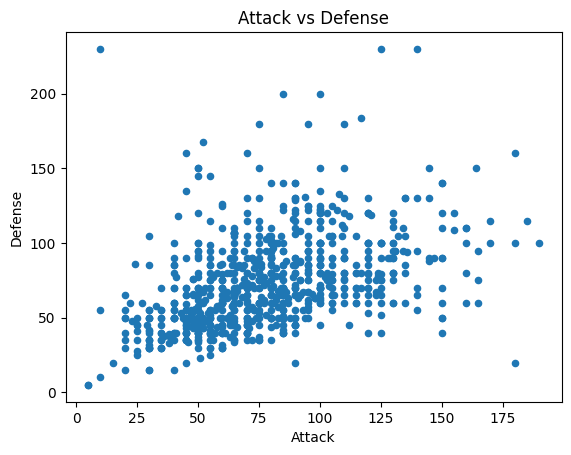

In [249]:
selected_df.plot.scatter(x='Attack', y='Defense')
plt.xlabel('Attack')
plt.ylabel('Defense')
plt.title('Attack vs Defense')
plt.show()

There is no missing values on my selected features.

# 3. Scale the Features (10 pts)

Apply StandardScaler to the selected features.

Show the transformed feature sample (e.g., first 5 rows) (10 pts)


In [250]:
scaler = StandardScaler()
selected_df[['HP', 'Attack', 'Defense']] = scaler.fit_transform(selected_df[['HP', 'Attack', 'Defense']])
selected_df.head(5)

/tmp/ipython-input-1192607404.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,HP,Attack,Defense
0,-0.950626,-0.924906,-0.797154
1,-0.362822,-0.524130,-0.347917
2,0.420917,0.092448,0.293849
3,0.420917,0.647369,1.577381
4,-1.185748,-0.832419,-0.989683


## 4. Determine a Suitable eps Value (10 pts)

Using k = 4:
Compute the distance to the 4th nearest neighbor for each Pokémon (6 pts)

In [251]:
nn = NearestNeighbors(n_neighbors=4).fit(selected_df)
distances, indices = nn.kneighbors(selected_df)

What is your chosen eps based on the "elbow"? (2 pts)

<function matplotlib.pyplot.show(close=None, block=None)>

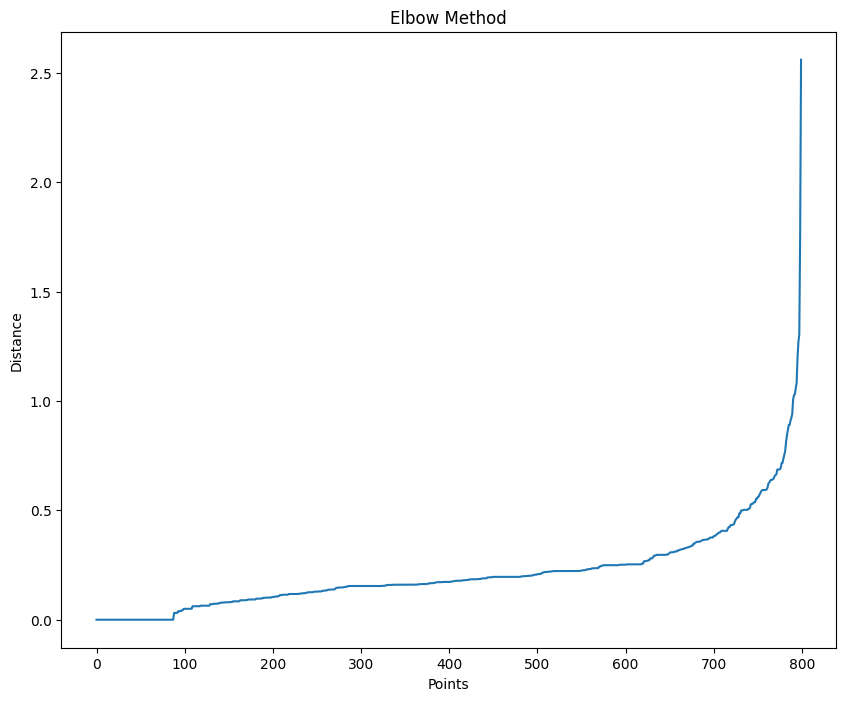

In [252]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(10, 8))
plt.plot(distances)
plt.xlabel('Points')
plt.ylabel('Distance')
plt.title('Elbow Method')
plt.show

In [253]:
min_samples = range(3,8)
epsilon = np.arange(0.3, 1.0, 0.1) # returns array of ranging from 0.05 to 0.13 with step of 0.01
epsilon

array([0.4, 0.5, 0.6, 0.7, 0.8])

One-sentence explanation of your reasoning (2 pts)

In [254]:
# put your answer here

## 5. Run DBSCAN (10 points)

Run DBSCAN using your chosen eps and min_samples


How many clusters did DBSCAN find? (4 pts)

In [255]:
# put your answer here

How many Pokémon were labeled as noise? (4 pts)

In [256]:
# put your answer here

Show the unique labels output by DBSCAN (2 pts)

In [257]:
# put your answer here

## 6. Attach Cluster Labels to the Original Dataset (7 points)

Add the cluster labels back to the original DataFrame (3 pts)

In [258]:
# put your answer here

Show the first 10 rows including the cluster label (4 pts)

In [259]:
# put your answer here

## 7. Explore the Clusters (12 points)

For each cluster:


How many Pokémon does it contain? (4 pts)

In [260]:
# put your answer here

What are the average Attack, Defense, and Speed? (4 pts)


In [261]:
# put your answer here

Compare the clusters: What differences do you notice? (4 pts)

In [262]:
# put your answer here

## 8. Identify Outliers (10 points)

List all Pokémon labeled as noise (cluster = -1) (4 pts)

In [263]:
# put your answer here

Are many of them legendary? (3 pts)

In [264]:
# put your answer here

Explain why DBSCAN might classify them as outliers (3 pts)

In [265]:
# put your answer here

## 9. Interpret the Clustering Results (25 points)
Write a short interpretation (4–6 sentences).
Discuss:


What types of Pokémon grouped together (5 pts)

In [266]:
# put your answer here

Whether the clusters make intuitive sense (10 pts)

In [267]:
# put your answer here


What the noise points reveal about DBSCAN (5 pts)


In [268]:
# put your answer here

What stat patterns you discovered (5 pts)

In [269]:
# put your answer here